In [1]:
!pip install shap

In [3]:
from google.colab import files
uploaded = files.upload()

Saving production_model_h1.pkl to production_model_h1.pkl


In [6]:
import pandas as pd

df = pd.read_csv("training_dataset.csv")

X = df.drop(columns=[
    "target_h1",
    "target_h2",
    "target_h3",
    "datetime"
], errors="ignore")

y = df["target_h1"]

In [7]:
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)

model.fit(X, y)

print("Model trained successfully in Colab")

Model trained successfully in Colab


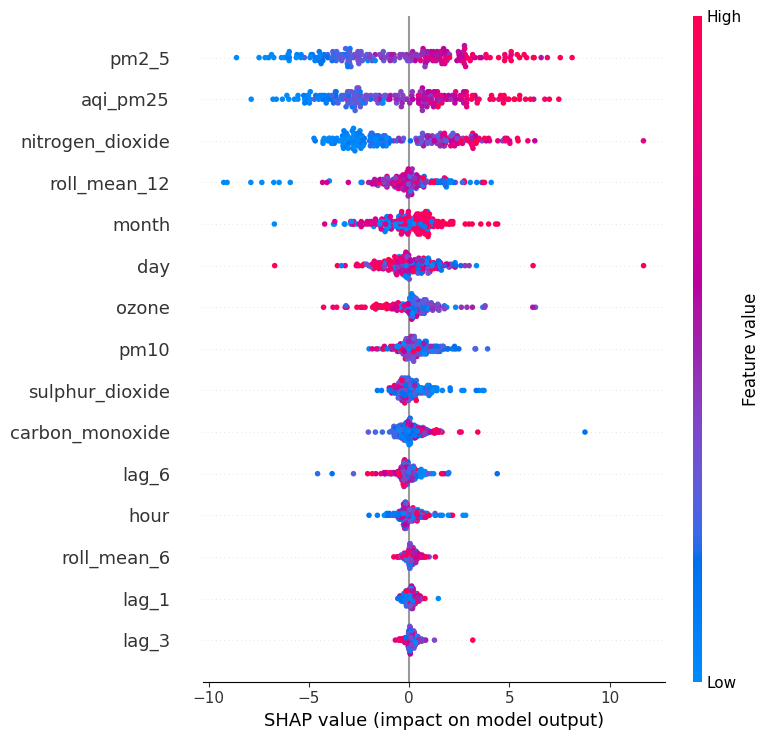

In [8]:
import shap

X_sample = X.sample(200, random_state=42)

explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_sample)

shap.summary_plot(shap_values, X_sample)

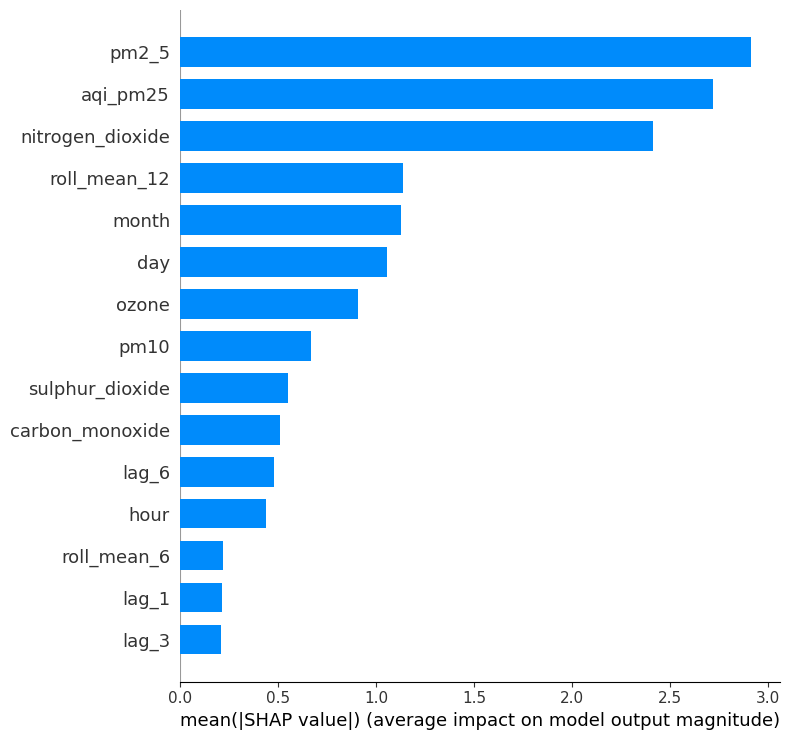

In [11]:
shap.summary_plot(shap_values, X_sample, plot_type="bar")